In [29]:
%pip install pillow numpy onnxruntime

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import io
import numpy as np
from PIL import Image
import onnxruntime as ort

# 모델 불러오기

In [2]:
sess = ort.InferenceSession('result.onnx')
sess

# 이미지를 바이트로 변환

In [12]:
with open("test.jpg", "rb") as f:
    img=f.read()

# 모델의 이미지 사이즈 가져오기(배치, 채널, 높이, 너비)

In [7]:
SIZE=sess.get_inputs()[0].shape[2:]
SIZE

[224, 224]

# 바이트를 이미지 분석용으로 가져오기

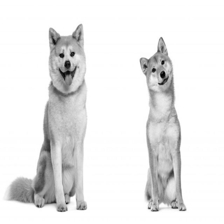

In [8]:
img = Image.open(io.BytesIO(img)).convert('RGB').resize(SIZE)
img

# 0~1로 정규화 하기

In [9]:
img_np = np.array(img, dtype=np.float32) / 255.0

# 정규화 하기

In [10]:
mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
chw_img = np.transpose((img_np - mean) / std, (2, 0, 1))
x = np.expand_dims(chw_img, axis=0)

# 결과 예측

In [11]:
classes = ['Lie', 'Seat', 'Stay']

input_name = sess.get_inputs()[0].name
outputs = sess.run(None, {input_name: x})
pred = classes[outputs[0].argmax()]
pred

'Seat'